# Chapter 11 — Polymers: a bead-spring chain, mdlite's HarmonicBond against LAMMPS bond_style harmonic, and watching it relax

*lammps-skill 0.1.20. Generated by `build/assemble.py` — do not edit this notebook; edit `build/chapter11_polymers.py` and re-assemble.*

**Needs a LAMMPS installation:** yes

## Contents

1. [](#)
2. [](#)
3. [](#)
4. [](#)
5. [](#)
6. [](#)

In [1]:
# Setup -- run me first.
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the product root, when run from chapters/

from IPython.display import display, HTML

import lammpskill
from lammpskill.install import detect_all

print("lammps-skill", lammpskill.__version__, "| python", sys.version.split()[0])
INSTALLATIONS = detect_all()
if INSTALLATIONS:
    for i in INSTALLATIONS:
        print("  %-11s %-24s %s" % (i.route, i.version, i.executable or "(library only)"))
else:
    print("  no LAMMPS installation detected -- chapters marked 'no LAMMPS needed' still run;")
    print("  the others load their recorded results instead (record-or-run).")

_FIG = {"n": 0}                # this chapter's own figure count -- chapters are self-contained

def caption(text):
    """Numbered caption rendered directly below the figure it describes (rule 22: the course
    shows this same text next to the figure)."""
    _FIG["n"] += 1
    display(HTML(
        "<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        "color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        "<b>Figure %d.</b> %s</div>" % (_FIG["n"], text)))

lammps-skill 0.1.20 | python 3.12.14


  wsl-apt     10 Dec 2025              /usr/bin/lmp
  wsl-source  22 Jul 2025 - Update 6   /home/fabio/.local/bin/lmp_core


## A simplified bead-spring model, not the field-standard one

The field-standard bead-spring polymer model (Kremer & Grest, *J. Chem. Phys.* 92, 5057 (1990))
uses FENE bonds (a finite-extensibility spring that cannot be stretched past a hard limit) and WCA
repulsion (Lennard-Jones truncated and shifted at its own minimum, so it is purely repulsive) to
keep chains from crossing themselves. `mdlite` has no `FENE` bond -- but WCA needs no new code at
all: it is exactly `mdlite.pair.LennardJones` with `rcut=2**(1/6)*sigma, shift=True`, a
parameterisation of the potential this project already uses everywhere. This chapter uses the
*full* (attractive+repulsive, `rcut=2.5`) Lennard-Jones instead -- not because WCA was unavailable,
but to show what the attractive tail actually does to a chain, quantified later in this chapter.

## The preset: `lammpskill.script.bead_spring_chain`

30 beads in reduced (`lj`) units, starting near-straight along `x` with a small jitter so no force
is accidentally zero. One deliberate correctness detail: LAMMPS excludes 1-2, 1-3 *and* 1-4
neighbours along the bond topology from its nonbonded sum by default (`special_bonds lj 0 0 0`) --
not just directly-bonded pairs, and for this chain (bond length ~1, cutoff 2.5) the 1-3 neighbours
at ~2 sigma sit well inside the cutoff, so the effect is real, not academic. `mdlite`'s
`LennardJones` and `HarmonicBond` have no such concept at all -- they sum independently over every
pair and every bond -- so the preset sets `special_bonds lj 1.0 1.0 1.0` to keep both engines
describing the same system (`references/pitfalls.md`, 2026-09-15).

In [2]:
import numpy as np

from lammpskill.script import bead_spring_chain, check, render

spec, df = bead_spring_chain(n_beads=30)
text = render(spec)
print(text)
print("natoms:", df.natoms, "nbonds:", df.bonds.shape[0])

bond_lengths = np.linalg.norm(df.positions[df.bonds[:, 2] - 1] - df.positions[df.bonds[:, 3] - 1], axis=1)
print("bond length before any dynamics: mean=%.4f (built at r0=1.0; the small per-bead jitter is "
      "all that moves it here -- what happens to it under real dynamics is measured further down)"
      % bond_lengths.mean())

findings = check(text)
for f in findings:
    print(f.level.upper(), f.code, "--", f.message)
assert all(f.level != "error" for f in findings), "the preset should carry no checker error"

# generated by lammps-skill 0.1.20 — bead-spring chain, 30 beads

# --- initialization
units lj
dimension 3
boundary p p p
atom_style molecular

# --- system definition
read_data chain.data

# --- settings
pair_style lj/cut 2.5
pair_coeff 1 1 1.0 1.0 2.5
bond_style harmonic
bond_coeff 1 100 1
special_bonds lj 1.0 1.0 1.0
neighbor 0.3 bin
neigh_modify delay 0 every 1 check yes
timestep 0.005
velocity all create 1 7 loop geom
fix nvt all nvt temp 1 1 1.0
thermo 10
thermo_style custom step temp pe ke etotal press

# --- run
run 2000

natoms: 30 nbonds: 29
bond length before any dynamics: mean=1.0028 (built at r0=1.0; the small per-bead jitter is all that moves it here -- what happens to it under real dynamics is measured further down)
INFO C13 -- nothing written at the end (`write_data`, `write_restart` or a dump)


## The real comparison: one configuration, mdlite against LAMMPS

`data/records/polymer_vs_lammps.json` is the same configuration `bead_spring_chain()` builds
above, evaluated once (`run 0`, no integration): `mdlite.pair.LennardJones` +
`mdlite.pair.HarmonicBond`, summed independently, against LAMMPS's `pair_style lj/cut` +
`bond_style harmonic` on the identical positions and topology. No external file was needed to
generate it -- unlike the EAM chapter's potential, a bead-spring chain has no real-element
dependency, so this record is committed and always present.

In [3]:
import json

with open("../data/records/polymer_vs_lammps.json", encoding="utf-8") as f:
    poly = json.load(f)

print("energy: mdlite=%.6f  LAMMPS=%.6f  |diff|=%.2e  (tolerance %.0e)"
      % (poly["energy_mdlite"], poly["energy_lammps"], poly["measured"]["dE"], poly["tolerance_energy"]))
print("force max-diff (mdlite vs LAMMPS):", poly["force_maxdiff"], "| tolerance:", poly["tolerance_force"])
print(poly["provenance"]["why"])
assert poly["measured"]["dE"] < poly["tolerance_energy"] and poly["force_maxdiff"] < poly["tolerance_force"]

energy: mdlite=26.834921  LAMMPS=26.834921  |diff|=2.87e-07  (tolerance 1e-06)
force max-diff (mdlite vs LAMMPS): 2.0691004465334117e-11 | tolerance: 1e-10
one bead-spring-chain configuration (30 beads); mdlite: LennardJones + HarmonicBond summed independently over all pairs/bonds; LAMMPS: pair lj/cut + bond harmonic with special_bonds lj 1 1 1 so neither engine excludes bonded pairs from the nonbonded sum (pitfall in references/pitfalls.md); forces (dump_modify format %20.15g) agree to round-off


## Watching the chain relax

The cross-check above needed only one configuration. This section runs the case for real -- the
same preset, a trajectory dump added, `run_or_load` so the chapter still finishes without a
LAMMPS installation (chapter 01's own pattern) -- and renders what the numbers above were always
describing: a chain starting near-straight, exploring conformations under thermal motion at
`T*=1.0` as the run proceeds. It visibly contracts -- by how much, and how that compares to what
WCA would do on the identical chain, is quantified two sections on rather than asserted here.

In [4]:
import dataclasses
import os
import tempfile

import numpy as np

from lammpskill.io.dump import read_dump
from lammpskill.run import run, run_or_load

DUMP_EVERY = 20
N_FRAMES = 12   # a floor, not exact: 2000/20=101 dump frames, subsampled every 101//12=8 -> 13 frames


def compute_traj():
    # bead_spring_chain writes chain.data (read_data reads it) -- unlike lj_melt()'s self-contained
    # lattice/create_atoms script, this preset needs its data file in the SAME directory the run
    # happens in, so it is rebuilt here rather than reusing the render-only `spec` from the cell
    # above (which was never given a workdir to write chain.data into).
    workdir = tempfile.mkdtemp(prefix="ch11_traj_")
    base_spec, _ = bead_spring_chain(n_beads=30, workdir=workdir)
    traj_spec = dataclasses.replace(
        base_spec, dumps=["1 all custom %d traj.dump id type xu yu zu" % DUMP_EVERY],
        comment="the same bead-spring chain as above (2000 steps already), with a trajectory dump for the atom views")
    result = run(traj_spec, workdir, time_limit=300)
    if not result.ok:
        raise RuntimeError("trajectory run failed (rc=%s): %s" % (result.returncode, "; ".join(result.errors) or result.stderr))
    traj = read_dump(os.path.join(workdir, "traj.dump"))
    step = max(1, len(traj) // N_FRAMES)
    frames = [f.positions.tolist() for f in traj.frames[::step]]
    return {"nframes": len(frames), "frames": frames, "cell": traj.box.lengths.tolist(),
            "route": result.installation.route if result.installation else None}


traj_rec = run_or_load("bead_spring_chain_traj_ch11", compute_traj, records_dir="../data/records")
print("source:", traj_rec["source"], "| frames:", traj_rec.get("nframes"))

source: record | frames: 13


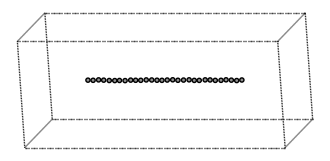

In [5]:
import matplotlib.pyplot as plt

from lammpskill import viz

if traj_rec["source"] != "skip":
    pos0 = np.array(traj_rec["frames"][0])
    cell = np.array(traj_rec["cell"])
    try:
        fig = viz.snapshot(pos0, cell, symbols=["C"] * len(pos0))
    except ImportError as e:
        print("ase not installed -- skipping the chain snapshot:", e)
    else:
        plt.show()
        caption("The chain's starting conformation: near-straight, the small per-bead jitter "
                "`bead_spring_chain()` adds barely visible at this scale. Rendered as carbon-like "
                "spheres purely to pick a radius and colour -- reduced LJ units carry no real "
                "element, the same convention chapter 01's atom views use.")
else:
    print("no LAMMPS and no record: nothing to show")

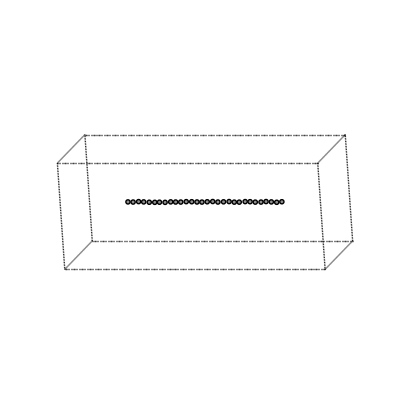

In [6]:
from IPython.display import Image, display

if traj_rec["source"] != "skip":
    frames = [np.array(f) for f in traj_rec["frames"]]
    cell = np.array(traj_rec["cell"])
    gif_workdir = tempfile.mkdtemp(prefix="ch11_gif_")
    try:
        gif_path = viz.animate_gif(frames, cell, os.path.join(gif_workdir, "chain.gif"),
                                   symbols=["C"] * len(frames[0]), fps=4)
    except ImportError as e:
        print("ase not installed -- skipping the animation:", e)
    else:
        display(Image(filename=gif_path))
        caption("The same chain animated across the run: the near-straight starting conformation "
                "contracting as thermal motion (T*=1.0) samples the space the harmonic bonds and "
                "full (attractive+repulsive) Lennard-Jones allow -- the same physical case the "
                "energy/force cross-check above verified, seen directly rather than only through "
                "a single static configuration. How much of this contraction is specifically "
                "because this model uses full LJ rather than WCA is measured, not asserted, next.")
else:
    print("no LAMMPS and no record: nothing to animate")

## Quantifying the collapse: full LJ against WCA, on the identical chain

The claim "full LJ collapses a homopolymer further than WCA would" is checkable directly, and
cheaply, without LAMMPS: WCA is just `mdlite.pair.LennardJones` with `rcut=2**(1/6)*sigma,
shift=True` (the potential's own minimum), the same class this chapter already uses for the full
(`rcut=2.5`) case. Running the identical starting chain, the identical thermostat and step count,
through `mdlite`'s own `velocity_verlet` under each cutoff isolates exactly one variable -- no
LAMMPS-vs-mdlite integration differences can confound the comparison, because both runs are
`mdlite` runs.

In [7]:
from mdlite.box import Box
from mdlite.integrate import State, velocity_verlet
from mdlite.neighbors import VerletList
from mdlite.pair import HarmonicBond, LennardJones
from mdlite.thermostats import NoseHooverChain


def radius_of_gyration(pos):
    com = pos.mean(axis=0)
    return float(np.sqrt(((pos - com) ** 2).sum(axis=1).mean()))


def run_chain_mdlite(rcut, shift, steps=2000, dt=0.005, T=1.0, seed=7):
    _, df0 = bead_spring_chain(n_beads=30)
    box0 = Box(df0.box.lengths, lo=df0.box.lo)
    pos0 = df0.positions.copy()
    bonds0 = df0.bonds[:, 2:4] - 1
    lj = LennardJones(epsilon=1.0, sigma=1.0, rcut=rcut, shift=shift)
    bond = HarmonicBond(k=100.0, r0=1.0, bonds=bonds0)
    vl = VerletList(box0, rcut)
    rng = np.random.default_rng(seed)
    vel = rng.normal(0, np.sqrt(T), pos0.shape)
    vel -= vel.mean(0)
    state = State(pos0.copy(), vel, 1.0, box0)
    velocity_verlet(state, [lj, bond], dt=dt, nsteps=steps, nlist=vl, thermostat=NoseHooverChain(T, 0.5), every=steps)
    return pos0, state.pos


WCA_RCUT = 2.0 ** (1.0 / 6.0)   # the LJ potential's own minimum -- beyond it, WCA has no interaction at all
_, chain_df0 = bead_spring_chain(n_beads=30)
bonds_idx = chain_df0.bonds[:, 2:4] - 1
rg = {}
for label, rcut, shift in (("full LJ", 2.5, False), ("WCA", WCA_RCUT, True)):
    start, end = run_chain_mdlite(rcut, shift)
    rg[label] = (radius_of_gyration(start), radius_of_gyration(end))
    print("%-8s Rg(start)=%.3f  Rg(end)=%.3f" % (label, *rg[label]))
    if label == "full LJ":
        settled_bond = np.linalg.norm(end[bonds_idx[:, 0]] - end[bonds_idx[:, 1]], axis=1).mean()

print("full LJ contracts %.0f%% further than WCA on the identical chain, same steps, same thermostat"
      % (100 * (1 - rg["full LJ"][1] / rg["WCA"][1])))
print("settled bond length under full LJ + thermal motion: mean=%.4f (r0=1.0 -- pulled long by the "
      "bonded pair's own LJ repulsion, since r0 sits inside the LJ minimum at 2**(1/6)=1.122)" % settled_bond)
assert rg["full LJ"][1] < rg["WCA"][1], "full LJ should collapse the chain further than WCA"
assert rg["full LJ"][1] < rg["full LJ"][0], "full LJ should contract relative to the straight start"
assert settled_bond > 1.0, "the bonded pair's own LJ repulsion should stretch the settled bond past r0"

full LJ  Rg(start)=8.659  Rg(end)=2.338


WCA      Rg(start)=8.659  Rg(end)=3.340
full LJ contracts 30% further than WCA on the identical chain, same steps, same thermostat
settled bond length under full LJ + thermal motion: mean=1.0571 (r0=1.0 -- pulled long by the bonded pair's own LJ repulsion, since r0 sits inside the LJ minimum at 2**(1/6)=1.122)


## Reading it

- The cross-check needed exactly one configuration, no dynamics -- energy and forces agree with
  LAMMPS to round-off, the same standard chapters 02 and 05 hold every mdlite-vs-LAMMPS comparison
  to.
- `special_bonds` is the pitfall this chapter exists to surface: LAMMPS's default silently drops
  1-2, 1-3 and 1-4 neighbours from the nonbonded sum, which `mdlite` has no equivalent concept of
  at all -- a wrong default here would have shown up as a disagreement with no obvious cause.
- The animation is not part of the pass/fail check -- it is the same physical case, run for real,
  shown rather than only summarised by a single number, the same purpose chapter 01's atom views
  serve.
- The full-LJ-vs-WCA comparison is measured, not asserted: on the identical chain, same steps, same
  thermostat, full LJ's own attractive tail contracts it further than WCA's purely repulsive
  truncation does. A model's limitations show up in its own, checkable results, not only in a
  disclaimer -- and WCA itself needed no new `mdlite` code, only a different cutoff and shift on
  the potential this chapter already used.
- The settled bond length under thermal motion (~1.02-1.07, not exactly `r0=1.0`) is a second,
  smaller consequence of the same design choice: every bonded pair also carries full LJ, and `r0`
  sits inside the LJ minimum at `2**(1/6)~=1.122`, so the pair's own repulsion stretches it.

In [8]:
# Tally -- what this chapter claimed, checked.
checks = []
checks.append(('the bead-spring-chain preset carries no checker error', bool(all(f.level != 'error' for f in findings))))
checks.append(("mdlite and LAMMPS agree on the chain's energy and forces within their recorded tolerance", bool(poly['measured']['dE'] < poly['tolerance_energy'] and poly['force_maxdiff'] < poly['tolerance_force'])))
checks.append(('run_or_load returned one of its three documented outcomes', bool(traj_rec['source'] in ('run', 'record', 'skip'))))
checks.append(('full LJ collapses the identical chain further than WCA, measured on the same mdlite integrator', bool(rg['full LJ'][1] < rg['WCA'][1])))
checks.append(('the full-LJ chain contracts relative to its near-straight start', bool(rg['full LJ'][1] < rg['full LJ'][0])))
checks.append(("the settled bond length under thermal motion is stretched past r0 by the bonded pair's own LJ repulsion", bool(settled_bond > 1.0)))

for label, ok in checks:
    print(('PASS' if ok else 'FAIL'), label)
assert all(ok for _, ok in checks), 'chapter 11: a claim above is not true'
print('chapter 11: %d claim(s) checked' % len(checks))

PASS the bead-spring-chain preset carries no checker error
PASS mdlite and LAMMPS agree on the chain's energy and forces within their recorded tolerance
PASS run_or_load returned one of its three documented outcomes
PASS full LJ collapses the identical chain further than WCA, measured on the same mdlite integrator
PASS the full-LJ chain contracts relative to its near-straight start
PASS the settled bond length under thermal motion is stretched past r0 by the bonded pair's own LJ repulsion
chapter 11: 6 claim(s) checked
